# Resolved Concentric Multigroup Diffusion Model

This notebook consumes one resolved OpenMC MGXS export through the backend adapter and cache. It preserves each exported OpenMC cell as a separate diffusion region, uses `D = 1 / (3 Sigma_tr)`, and solves with only the non-`nu` P0 scattering matrix.

The canonical diffusion export must declare `scatter_correction = null`. Newly generated OpenMC MG validation libraries use supplemental P0-corrected consistent scattering tallies from the same continuous-energy run, but those corrected matrices are not diffusion inputs. See [diffusion_mgxs_workflow.md](diffusion_mgxs_workflow.md) for the full contract.

The clean unrodded solve is the baseline. A power shape correction is then done. The SPH chapter then compares resolved region/group fluxes against the continuous-energy reference, diagnoses the fixed-point iteration, and persists factors only after convergence and qualification.

In [18]:
from pathlib import Path
from pprint import pprint
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import openmc

project_root = Path.cwd()
if not (project_root / "backend").is_dir():
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "backend"))
sys.path.insert(0, str(project_root / "openmc"))

from reactor_backend.diffusion import rho_pcm
from reactor_backend.multigroup_diffusion import (
    BOUNDARY_GROUPWISE_FVM,
    ConcentricMeshSpacing,
)
from reactor_backend.multigroup_diffusion_cache import (
    DiffusionCacheSettings,
    prepare_concentric_diffusion_cache,
)
from reactor_backend.multigroup_sph import normalized_power_profiles
from reactor_backend.openmc_mgxs_adapter import load_concentric_diffusion_input
from mgxs_export import MGXSExportConfig, run_openmc_mg_validation

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})


def _peak_normalise(values):
    values = np.ma.asarray(values, dtype=float)
    if values.size == 0:
        return np.ma.zeros(values.shape, dtype=float)
    scale = float(np.ma.max(values))
    if not np.isfinite(scale) or scale <= 0.0:
        return np.ma.zeros(values.shape, dtype=float)
    return values / scale


def _mirror_cylindrical_plane(values, r_edges):
    values = np.ma.asarray(values)
    r_edges = np.asarray(r_edges, dtype=float)
    if values.ndim != 2:
        raise ValueError(f"Expected a 2D (r, z) array, got shape {values.shape}.")
    if values.shape[0] != r_edges.size - 1:
        raise ValueError(
            f"Radial bin mismatch: values has {values.shape[0]} bins, "
            f"but r_edges defines {r_edges.size - 1}."
        )
    x_edges = np.concatenate((-r_edges[:0:-1], r_edges))
    mirrored = np.ma.concatenate((values[::-1, :], values), axis=0).T
    return x_edges, mirrored


## 1. Select, Validate, and Prepare the Export

`MGXS_EXPORT_DIR` selects both `outputs/mgxs_constants.json` and the colocated `reactor_run/model.xml`. It points to the tracked four-group publication; change only `GROUP_COUNT` to select another published sweep member.

A cache miss builds one CSR spatial matrix per group and solves the clean state synchronously. A cache hit reloads the mesh, material arrays, matrices, and clean result. SuperLU factors remain process-local and are not serialized.

In [19]:
GROUP_COUNT = 4
MGXS_EXPORT_DIR = (
    project_root
    / "openmc"
    / "reference_data"
    / "concentric"
    / "group_sweep"
    / f"group_{GROUP_COUNT}"
)

MESH_SPACING = ConcentricMeshSpacing(
    fuel_radial_cm=0.1,
    core_coolant_radial_cm=1.0,
    moderator_radial_cm=5.0,
    reflector_radial_cm=20.0,
    axial_cm=10.0,
)
CACHE_SETTINGS = DiffusionCacheSettings(
    spacing=MESH_SPACING,
    delta_absorption_rod=0.0,
    boundary_condition=BOUNDARY_GROUPWISE_FVM,
    max_iter=300,
    tol=1.0e-5,
    source_tol=1.0e-3,
    max_inner_iter=200,
    inner_tol=1.0e-4,
)

DIFFUSION_INPUT = load_concentric_diffusion_input(MGXS_EXPORT_DIR)
PREPARED = prepare_concentric_diffusion_cache(
    DIFFUSION_INPUT,
    settings=CACHE_SETTINGS,
)
INPUT_SUMMARY = DIFFUSION_INPUT.summary()
model_2d = PREPARED.system.model
mesh = PREPARED.system.mesh
sol_clean = PREPARED.clean_solution
geometry = DIFFUSION_INPUT.geometry

print("=== DIFFUSION INPUT AND CACHE ===")
print(f"Export                    = {DIFFUSION_INPUT.export_dir}")
print(f"Energy groups              = {DIFFUSION_INPUT.group_count}")
print(f"Source Legendre order      = P{DIFFUSION_INPUT.source_legendre_order}")
print("Diffusion scattering       = non-nu P0")
print(f"Canonical correction       = {INPUT_SUMMARY['scatter_correction']}")
print(f"MG validation correction   = {INPUT_SUMMARY['validation_scatter_correction']}")
print(f"Scatter matrix source(s)   = {INPUT_SUMMARY['validation']['scatter_matrix_sources']}")
print(f"Higher moments discarded   = {INPUT_SUMMARY['discarded_higher_moments']}")
print(f"Resolved zones             = {INPUT_SUMMARY['zone_count']}")
print(f"Cache hit                  = {PREPARED.cache_hit}")
print(f"Cache directory            = {PREPARED.cache_dir}")
print(f"Mesh                       = {mesh.nr} x {mesh.nz} = {mesh.cell_count:,} cells")
print(f"Group-matrix nonzeros      = {sum(matrix.nnz for matrix in PREPARED.system.operators):,}")
print(f"Max D consistency error    = {INPUT_SUMMARY['validation']['max_diffusion_relative_error']:.3e}")
print(f"Sanitized MGXS domains     = {INPUT_SUMMARY['validation']['sanitized_domain_count']}")
if DIFFUSION_INPUT.ce_reference is None:
    raise RuntimeError("This notebook requires the continuous-energy reference payload")
reference_std_pcm = DIFFUSION_INPUT.openmc_reference['keff_std_dev'] * 1.0e5
power_mesh = DIFFUSION_INPUT.ce_reference.power_mesh
print(f"CE k_eff uncertainty       = {reference_std_pcm:.1f} pcm")
print(f"CE region/group flux       = {len(DIFFUSION_INPUT.ce_reference.region_flux)} regions")
print(
    "CE kappa-fission mesh    = "
    + ("absent" if power_mesh is None else f"{power_mesh.mean.shape[0]} x {power_mesh.mean.shape[1]}")
)

sanitized = {
    label: domain['diffusion_replacements']
    for label, domain in INPUT_SUMMARY['validation']['domains'].items()
    if domain['diffusion_replacements']
}
if sanitized:
    print("\nInactive-group diffusion replacements")
    pprint(sanitized, sort_dicts=False)

print("=== XML-DERIVED RESOLVED ZONES ===")
for zone in DIFFUSION_INPUT.zone_report:
    print(
        f"{zone['label']:>42}: "
        f"r=[{zone['r_min_cm']:.1f}, {zone['r_max_cm']:.1f}] cm, "
        f"z=[{zone['z_min_cm']:.1f}, {zone['z_max_cm']:.1f}] cm"
    )


=== DIFFUSION INPUT AND CACHE ===
Export                    = /home/pablo/modelica/repo-codex-a/openmc/reference_data/concentric/group_sweep/group_4
Energy groups              = 4
Source Legendre order      = P0
Diffusion scattering       = non-nu P0
Canonical correction       = None
MG validation correction   = P0
Scatter matrix source(s)   = ['consistent scatter matrix']
Higher moments discarded   = False
Resolved zones             = 12
Cache hit                  = True
Cache directory            = /home/pablo/modelica/repo-codex-a/backend/.cache/openmc_diffusion/0d7a940fd854703f5c3edefbe4a433248a0ca597d865d18465464c02c7cd18c1
Mesh                       = 135 x 100 = 13,500 cells
Group-matrix nonzeros      = 268,120
Max D consistency error    = 2.208e-16
Sanitized MGXS domains     = 1
CE k_eff uncertainty       = 21.8 pcm
CE region/group flux       = 12 regions
CE kappa-fission mesh    = 100 x 100

Inactive-group diffusion replacements
{'reflector': [{'group': 1,
                'ori

## 2. Clean-Core Stability Result

The cached clean result is the uncorrected numerical baseline. Its difference from continuous-energy OpenMC is not removed by adjusting `k_eff` directly; the following SPH iteration is driven by resolved region/group flux equivalence.

In [20]:
k_diff = sol_clean['k_eff']
rho_diff_pcm = rho_pcm(k_diff)
openmc_reference = DIFFUSION_INPUT.openmc_reference
if not sol_clean['converged'] or not np.isfinite(k_diff) or k_diff <= 0.0:
    raise RuntimeError(f"Invalid clean diffusion result: {k_diff}")

print("=== CLEAN UNRODDED DIFFUSION SOLVE ===")
print(f"Diffusion k_eff            = {k_diff:.6f}")
print(f"Diffusion reactivity       = {rho_diff_pcm:+.1f} pcm")
print(f"OpenMC CE k_eff            = {openmc_reference['keff']:.6f}")
print(f"Delta k                    = {k_diff - openmc_reference['keff']:+.6f}")
print(f"Outer iterations           = {sol_clean['iterations']}")
print(f"Final balance residual     = {sol_clean['balance_residual']:.3e}")
print(f"Prepared solve time        = {sol_clean['timings_s']['total']:.3f} s")


=== CLEAN UNRODDED DIFFUSION SOLVE ===
Diffusion k_eff            = 1.001429
Diffusion reactivity       = +142.7 pcm
OpenMC CE k_eff            = 1.001420
Delta k                    = +0.000009
Outer iterations           = 36
Final balance residual     = 2.719e-05
Prepared solve time        = 1.507 s


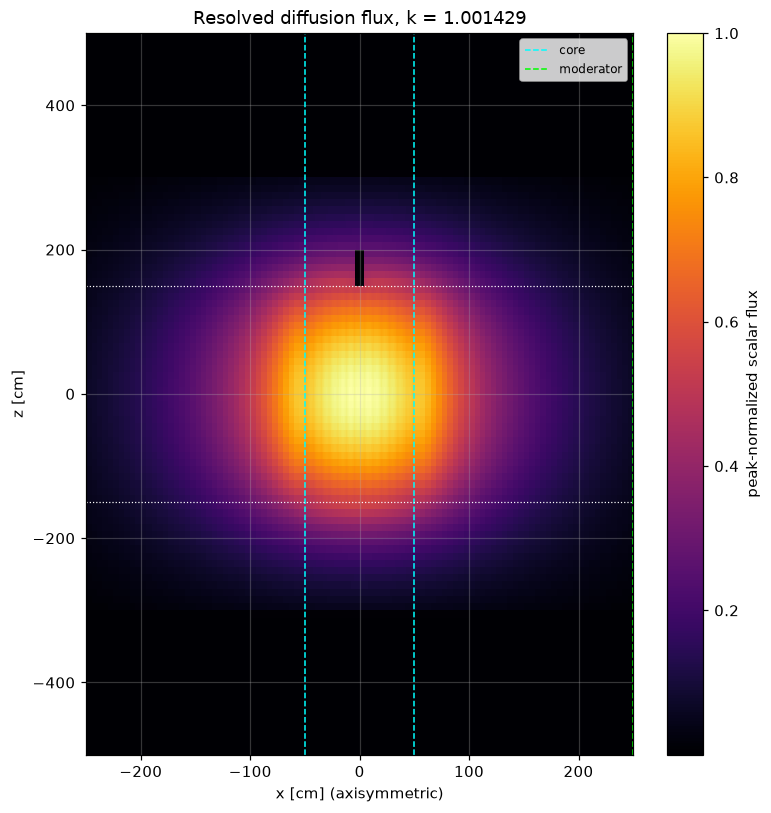

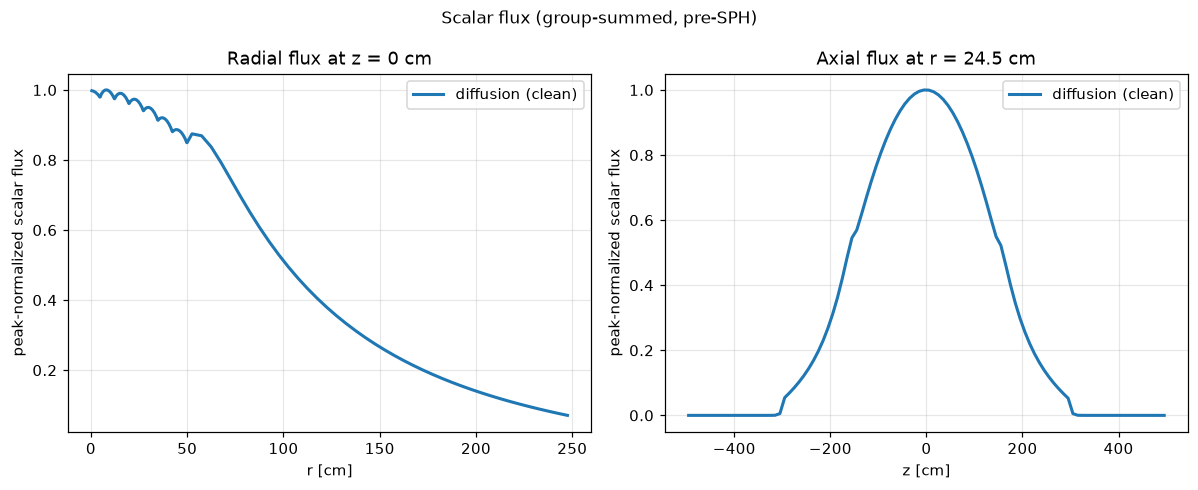

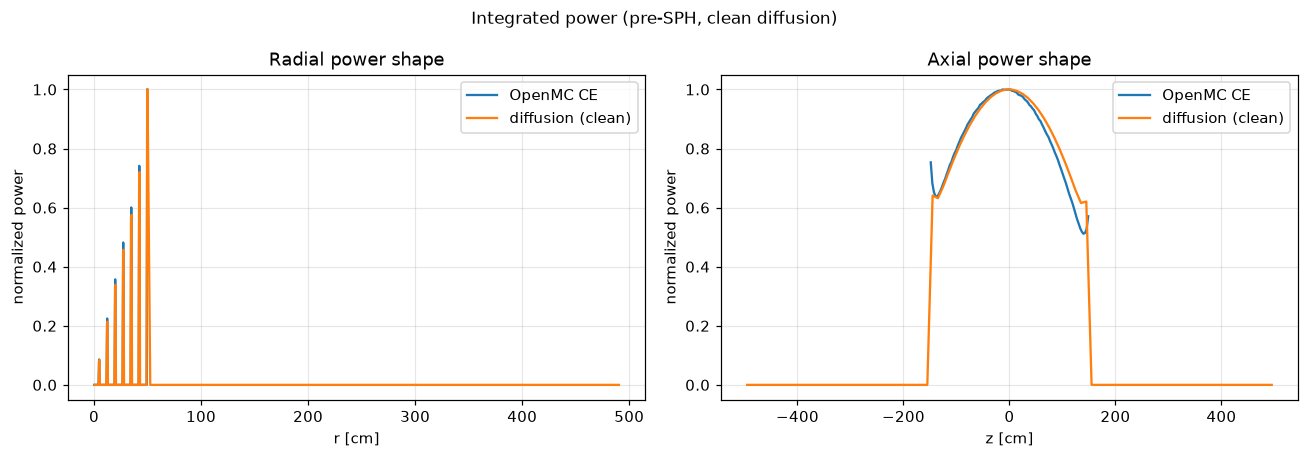

In [21]:
phi_clean = sol_clean['phi']
r_grid = sol_clean['r_grid']
z_grid = sol_clean['z_grid']
r_edges = sol_clean['r_edges']
z_edges = sol_clean['z_edges']

# Display only the D2O moderator tank radius, matching the OpenMC MG flux mesh.
moderator_radius = float(geometry['moderator_radius_cm'])
moderator_edge = np.flatnonzero(np.isclose(r_edges, moderator_radius, rtol=0.0, atol=1.0e-8))
if moderator_edge.size == 0:
    raise RuntimeError(f"Moderator radius {moderator_radius} cm is not a diffusion mesh edge.")
r_stop = int(moderator_edge[-1]) + 1
r_edges_display = r_edges[:r_stop]
phi_display = phi_clean[: r_stop - 1, :]

x_edges, phi_2d = _mirror_cylindrical_plane(phi_display, r_edges_display)
phi_2d = _peak_normalise(phi_2d)

fig, ax = plt.subplots(figsize=(7.2, 7.5))
image = ax.pcolormesh(
    x_edges,
    z_edges,
    phi_2d,
    cmap='inferno',
    shading='flat',
)
for radius, color, label in (
    (geometry['core_radius_cm'], 'cyan', 'core'),
    (geometry['moderator_radius_cm'], 'lime', 'moderator'),
):
    ax.axvline(radius, color=color, lw=1.0, ls='--', label=label)
    ax.axvline(-radius, color=color, lw=1.0, ls='--')
ax.axhline(model_2d.core_height / 2, color='white', lw=0.8, ls=':')
ax.axhline(-model_2d.core_height / 2, color='white', lw=0.8, ls=':')
fig.colorbar(image, ax=ax, label='peak-normalized scalar flux')
ax.set(xlabel='x [cm] (axisymmetric)', ylabel='z [cm]', title=f'Resolved diffusion flux, k = {k_diff:.6f}')
ax.legend(loc='upper right', fontsize=8)
plt.tight_layout()
plt.show()

midplane = int(np.argmin(np.abs(z_grid)))
probe = int(np.argmin(np.abs(r_grid - 0.5 * geometry['core_radius_cm'])))

# ── Scalar flux profiles ───────────────────────────────────────────────
fig_flux, (ax_rf, ax_zf) = plt.subplots(1, 2, figsize=(11, 4.5))
ax_rf.plot(r_grid[r_grid <= moderator_radius], _peak_normalise(phi_clean[r_grid <= moderator_radius, midplane]),
           lw=2, color="tab:blue", label="diffusion (clean)")
ax_rf.set(xlabel="r [cm]", ylabel="peak-normalized scalar flux",
          title="Radial flux at z = 0 cm")
ax_rf.legend()

ax_zf.plot(z_grid, _peak_normalise(phi_clean[probe, :]),
           lw=2, color="tab:blue", label="diffusion (clean)")
ax_zf.set(xlabel="z [cm]", ylabel="peak-normalized scalar flux",
          title=f"Axial flux at r = {r_grid[probe]:.1f} cm")
ax_zf.legend()
plt.suptitle("Scalar flux (group-summed, pre-SPH)", fontsize=11)
plt.tight_layout()
plt.show()

# ── Power profiles: diffusion vs OpenMC CE ──────────────────────────────
if power_mesh is not None:
    ce_radial = np.sum(power_mesh.mean, axis=1) / np.diff(power_mesh.r_edges_cm)
    ce_axial = np.sum(power_mesh.mean, axis=0) / np.diff(power_mesh.z_edges_cm)
    ce_radial /= np.max(ce_radial)
    ce_axial /= np.max(ce_axial)
    ce_r = 0.5 * (power_mesh.r_edges_cm[:-1] + power_mesh.r_edges_cm[1:])
    ce_z = 0.5 * (power_mesh.z_edges_cm[:-1] + power_mesh.z_edges_cm[1:])

    diffusion_power = normalized_power_profiles(PREPARED.system, sol_clean)
    fig, (ax_r, ax_z) = plt.subplots(1, 2, figsize=(12.0, 4.2))
    ax_r.plot(ce_r, ce_radial, label='OpenMC CE')
    ax_r.plot(diffusion_power['radial_axis_cm'], diffusion_power['radial'], label='diffusion (clean)')
    ax_r.set(xlabel='r [cm]', ylabel='normalized power', title='Radial power shape')
    ax_z.plot(ce_z, ce_axial, label='OpenMC CE')
    ax_z.plot(diffusion_power['axial_axis_cm'], diffusion_power['axial'], label='diffusion (clean)')
    ax_z.set(xlabel='z [cm]', ylabel='normalized power', title='Axial power shape')
    ax_r.legend()
    ax_z.legend()
    plt.suptitle("Integrated power (pre-SPH, clean diffusion)", fontsize=11)
    plt.tight_layout()
    plt.show()
else:
    print("No CE power mesh available for comparison.")


### OpenMC Multigroup Comparison

The scalar-flux image uses the same full-plane, peak-normalized display convention as the diffusion plot above. OpenMC mesh flux tallies are first divided by cylindrical bin volume to show flux density rather than annular-bin-integrated flux.


In [22]:
# ── OpenMC multigroup run with flux mesh tallies ────────────────────────
# This must use the CE statepoint that produced this exact MGXS library,
# not a plain continuous-energy reactor statepoint with different cell ids.
_mgxs_payload = json.loads((MGXS_EXPORT_DIR / "outputs" / "mgxs_constants.json").read_text())
_statepoint_metadata = _mgxs_payload.get("statepoint_path")
_statepoint_name = Path(_statepoint_metadata).name if _statepoint_metadata else "statepoint.100.h5"
_candidate_ce_statepoints = [
    Path(_statepoint_metadata).expanduser() if _statepoint_metadata else None,
    project_root / "openmc" / "build" / "concentric" / "mgxs_export" / "group_sweep" / f"group_{GROUP_COUNT}" / "reactor_run" / _statepoint_name,
    MGXS_EXPORT_DIR / "reactor_run" / _statepoint_name,
]
CE_STATEPOINT_PATH = next(
    (path for path in _candidate_ce_statepoints if path is not None and path.exists()),
    next(path for path in _candidate_ce_statepoints if path is not None),
)
MG_MESH_VALIDATION_DIR = MGXS_EXPORT_DIR / "mg_mode_validation_with_flux"
MG_MESH_VALIDATION_RESULTS = MG_MESH_VALIDATION_DIR / "validation_results.json"

if MG_MESH_VALIDATION_RESULTS.exists():
    mg_result = json.loads(MG_MESH_VALIDATION_RESULTS.read_text())
    mg_sp_path = Path(mg_result.get("statepoint_path", mg_result.get("files", {}).get("statepoint", "")))
    mg_keff = mg_result["run"]["keff"]
    if not mg_sp_path.exists():
        raise FileNotFoundError(f"Cached MG validation statepoint is missing: {mg_sp_path}")
    print(f"Using cached OpenMC MG validation = {MG_MESH_VALIDATION_RESULTS}")
elif CE_STATEPOINT_PATH.exists():
    print(f"Using MGXS CE statepoint = {CE_STATEPOINT_PATH}")
    _mgxs_config_dict = _mgxs_payload["config"]
    mg_config = MGXSExportConfig(
        particles=_mgxs_config_dict["particles"],
        batches=_mgxs_config_dict["batches"],
        inactive=_mgxs_config_dict["inactive"],
        domain_definitions=tuple(tuple(item) for item in _mgxs_config_dict["domain_definitions"]),
        energy_group_edges_ev=tuple(_mgxs_config_dict["energy_group_edges_ev"]),
        mgxs_types=tuple(_mgxs_config_dict["mgxs_types"]),
        delayed_groups=tuple(_mgxs_config_dict.get("delayed_groups", (1, 2, 3, 4, 5, 6))),
        legendre_order=int(_mgxs_config_dict.get("legendre_order", 0)),
        scatter_correction=None,
        validation_scatter_correction=str(_mgxs_config_dict.get("validation_scatter_correction", "P0")),
    )

    r_max_global = geometry["moderator_radius_cm"]
    z_half_global = float(sol_clean["z_edges"][-1])
    r_max_fuel = geometry["core_radius_cm"]
    z_half_fuel = float(model_2d.core_height / 2)

    global_mg_mesh = openmc.CylindricalMesh(
        r_grid=np.linspace(0.0, r_max_global, 81),
        phi_grid=np.asarray([0.0, 2.0 * np.pi]),
        z_grid=np.linspace(-z_half_global, z_half_global, 81),
    )
    fuel_mg_mesh = openmc.CylindricalMesh(
        r_grid=np.linspace(0.0, r_max_fuel, 101),
        phi_grid=np.asarray([0.0, 2.0 * np.pi]),
        z_grid=np.linspace(-z_half_fuel, z_half_fuel, 101),
    )

    mg_mesh_tallies = []
    for mesh_name, mesh_for_tally in [("global-mesh-mg", global_mg_mesh), ("fuel-mesh-mg", fuel_mg_mesh)]:
        tally = openmc.Tally(name=mesh_name)
        tally.filters = [openmc.MeshFilter(mesh_for_tally)]
        tally.scores = ["flux", "fission", "nu-fission", "kappa-fission"]
        mg_mesh_tallies.append(tally)

    print("Running OpenMC multigroup with flux tallies ...")
    mg_result = run_openmc_mg_validation(
        statepoint_path=CE_STATEPOINT_PATH,
        config=mg_config,
        model_path_or_dir=DIFFUSION_INPUT.model_xml_path,
        output_dir=MG_MESH_VALIDATION_DIR,
        particles=40000,
        batches=100,
        inactive=20,
        threads=OPENMC_THREADS if "OPENMC_THREADS" in globals() else None,
        mesh_tallies=mg_mesh_tallies,
    )
    mg_sp_path = Path(mg_result["statepoint_path"])
    mg_keff = mg_result["run"]["keff"]
else:
    raise FileNotFoundError(
        f"MGXS CE statepoint not found at {CE_STATEPOINT_PATH}. "
        "Rerun the MGXS export for this group, or point CE_STATEPOINT_PATH "
        "at the reactor_run/statepoint.*.h5 that produced this MGXS library."
    )

print(f"MG k_eff = {mg_keff['mean']:.6f} +/- {mg_keff['std_dev']:.6f}")
print(f"CE k_eff = {openmc_reference['keff']:.6f}")
delta_pcm = (mg_keff["mean"] - openmc_reference["keff"]) / mg_keff["mean"] * 1.0e5
print(f"Delta rho(MG - CE) = {delta_pcm:+.1f} pcm")

# ── Load MG flux and power from statepoint ───────────────────────────
with openmc.StatePoint(mg_sp_path) as mg_sp:
    mg_flux_tally = mg_sp.get_tally(name="global-mesh-mg").get_slice(scores=["flux"])
    mg_flux_mesh = mg_flux_tally.filters[0].mesh
    mg_flux_raw = np.squeeze(mg_flux_tally.get_reshaped_data(value="mean", expand_dims=True))

    mg_power_tally = mg_sp.get_tally(name="fuel-mesh-mg").get_slice(scores=["kappa-fission"])
    mg_power_mesh = mg_power_tally.filters[0].mesh
    mg_power_raw = np.squeeze(mg_power_tally.get_reshaped_data(value="mean", expand_dims=True))


Using cached OpenMC MG validation = /home/pablo/modelica/repo-codex-a/openmc/reference_data/concentric/group_sweep/group_4/mg_mode_validation_with_flux/validation_results.json
MG k_eff = 1.005047 +/- 0.000315
CE k_eff = 1.001420
Delta rho(MG - CE) = +360.8 pcm


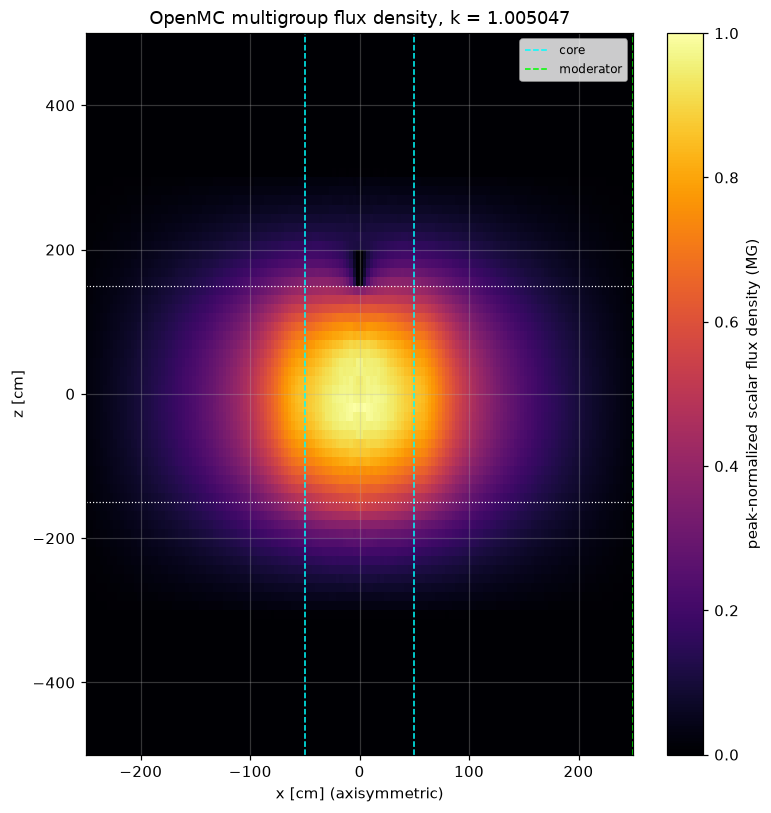

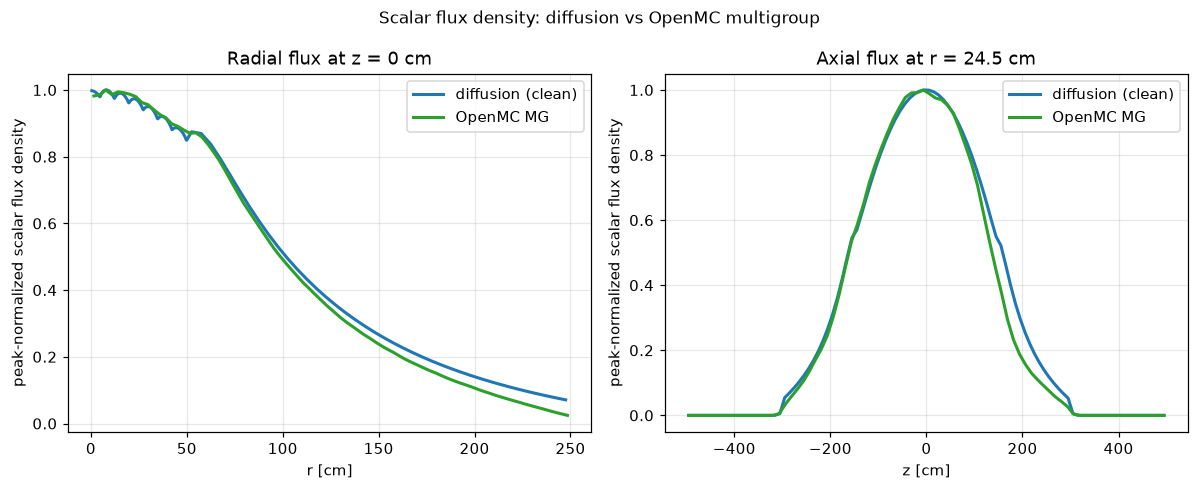

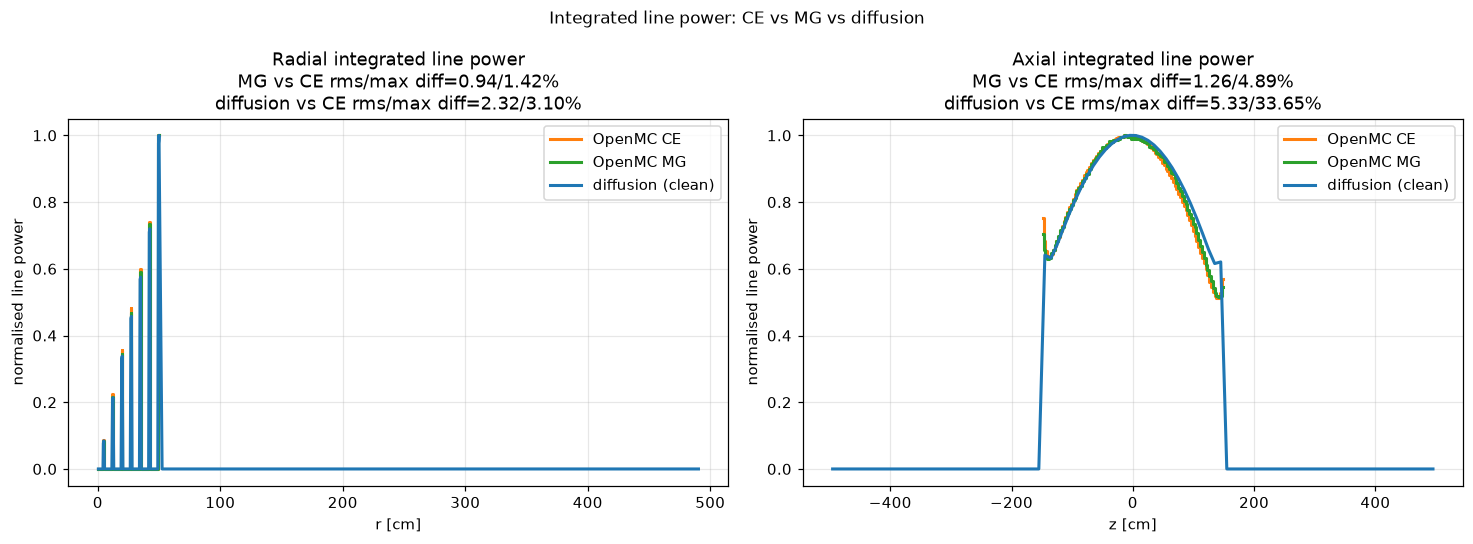

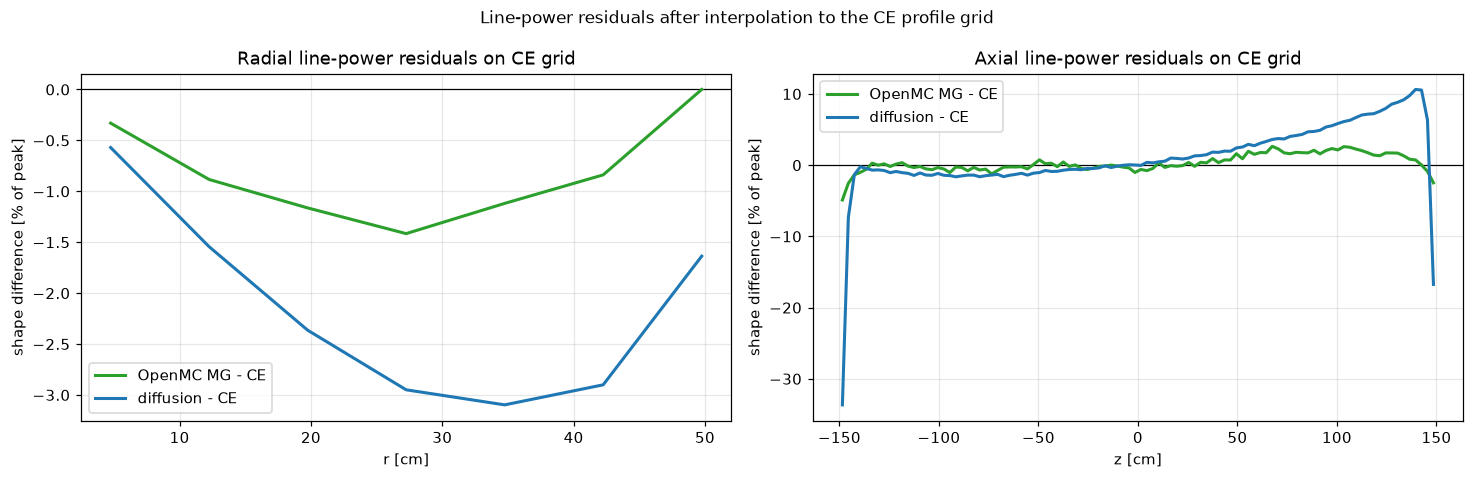

In [23]:
def _profile_error(candidate_axis, candidate_values, reference_axis, reference_values, *, active_floor=0.02):
    candidate_on_reference = np.interp(
        reference_axis,
        np.asarray(candidate_axis, dtype=float),
        np.asarray(candidate_values, dtype=float),
        left=np.nan,
        right=np.nan,
    )
    reference_values = np.asarray(reference_values, dtype=float)
    reference_scale = np.nanmax(reference_values) if reference_values.size else np.nan
    active = (
        np.isfinite(candidate_on_reference)
        & np.isfinite(reference_values)
        & np.isfinite(reference_scale)
        & (reference_values > active_floor * reference_scale)
    )
    if not np.any(active):
        return {"rms": np.nan, "maximum": np.nan, "on_reference": candidate_on_reference, "active": active}
    difference = candidate_on_reference[active] - reference_values[active]
    return {
        "rms": float(np.sqrt(np.mean(difference**2))),
        "maximum": float(np.max(np.abs(difference))),
        "on_reference": candidate_on_reference,
        "active": active,
    }


def _error_label(error):
    return f"rms/max diff={100.0 * error['rms']:.2f}/{100.0 * error['maximum']:.2f}%"


# ── 2D flux image ────────────────────────────────────────────────────
mg_flux_volumes = np.asarray(mg_flux_mesh.volumes, dtype=float).reshape(tuple(mg_flux_mesh.dimension)).squeeze()
mg_flux_density = np.zeros_like(mg_flux_raw, dtype=float)
np.divide(mg_flux_raw, mg_flux_volumes, out=mg_flux_density, where=mg_flux_volumes > 0.0)
r_mg_edges = np.asarray(mg_flux_mesh.r_grid, dtype=float)
z_mg_edges = np.asarray(mg_flux_mesh.z_grid, dtype=float)
x_mg_edges, mg_flux_2d = _mirror_cylindrical_plane(mg_flux_density, r_mg_edges)
mg_flux_2d = _peak_normalise(mg_flux_2d)
r_mg = 0.5 * (r_mg_edges[:-1] + r_mg_edges[1:])
z_mg = 0.5 * (z_mg_edges[:-1] + z_mg_edges[1:])

fig_mg, ax_mg = plt.subplots(figsize=(7.2, 7.5))
im_mg = ax_mg.pcolormesh(
    x_mg_edges,
    z_mg_edges,
    mg_flux_2d,
    shading="flat",
    cmap="inferno",
)
for radius, color, label in (
    (geometry["core_radius_cm"], "cyan", "core"),
    (geometry["moderator_radius_cm"], "lime", "moderator"),
):
    ax_mg.axvline(radius, color=color, lw=1.0, ls="--", label=label)
    ax_mg.axvline(-radius, color=color, lw=1.0, ls="--")
ax_mg.axhline(model_2d.core_height / 2, color="white", lw=0.8, ls=":")
ax_mg.axhline(-model_2d.core_height / 2, color="white", lw=0.8, ls=":")
fig_mg.colorbar(im_mg, ax=ax_mg, label="peak-normalized scalar flux density (MG)")
ax_mg.set(xlabel="x [cm] (axisymmetric)", ylabel="z [cm]",
          title=f"OpenMC multigroup flux density, k = {mg_keff['mean']:.6f}")
ax_mg.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

# ── Scalar flux profiles: MG vs diffusion ────────────────────────────
mg_flux_midplane = mg_flux_density[:, int(np.argmin(np.abs(z_mg)))]
mg_flux_probe = mg_flux_density[int(np.argmin(np.abs(r_mg - 0.5 * geometry["core_radius_cm"]))), :]
diffusion_radial_active = r_grid <= float(geometry["moderator_radius_cm"])

fig_fx, (ax_rf, ax_zf) = plt.subplots(1, 2, figsize=(11, 4.5))
ax_rf.plot(r_grid[diffusion_radial_active], _peak_normalise(phi_clean[diffusion_radial_active, midplane]),
           lw=2, color="tab:blue", label="diffusion (clean)")
ax_rf.plot(r_mg, _peak_normalise(mg_flux_midplane),
           lw=2, color="tab:green", label="OpenMC MG")
ax_rf.set(xlabel="r [cm]", ylabel="peak-normalized scalar flux density",
          title="Radial flux at z = 0 cm")
ax_rf.legend()

ax_zf.plot(z_grid, _peak_normalise(phi_clean[probe, :]),
           lw=2, color="tab:blue", label="diffusion (clean)")
ax_zf.plot(z_mg, _peak_normalise(mg_flux_probe),
           lw=2, color="tab:green", label="OpenMC MG")
ax_zf.set(xlabel="z [cm]", ylabel="peak-normalized scalar flux density",
          title=f"Axial flux at r = {r_grid[probe]:.1f} cm")
ax_zf.legend()
plt.suptitle("Scalar flux density: diffusion vs OpenMC multigroup", fontsize=11)
plt.tight_layout()
plt.show()

# ── Integrated line-power profiles: MG vs CE vs diffusion ────────────
r_pmg_edges = np.asarray(mg_power_mesh.r_grid, dtype=float)
z_pmg_edges = np.asarray(mg_power_mesh.z_grid, dtype=float)
r_pmg = 0.5 * (r_pmg_edges[:-1] + r_pmg_edges[1:])
z_pmg = 0.5 * (z_pmg_edges[:-1] + z_pmg_edges[1:])

mg_radial = _peak_normalise(np.sum(mg_power_raw, axis=1) / np.diff(r_pmg_edges))
mg_axial = _peak_normalise(np.sum(mg_power_raw, axis=0) / np.diff(z_pmg_edges))

if power_mesh is not None:
    ce_radial = _peak_normalise(np.sum(power_mesh.mean, axis=1) / np.diff(power_mesh.r_edges_cm))
    ce_axial = _peak_normalise(np.sum(power_mesh.mean, axis=0) / np.diff(power_mesh.z_edges_cm))
    ce_r = 0.5 * (power_mesh.r_edges_cm[:-1] + power_mesh.r_edges_cm[1:])
    ce_z = 0.5 * (power_mesh.z_edges_cm[:-1] + power_mesh.z_edges_cm[1:])

    diffusion_power = normalized_power_profiles(PREPARED.system, sol_clean)
    diffusion_radial = _peak_normalise(diffusion_power["radial"])
    diffusion_axial = _peak_normalise(diffusion_power["axial"])

    mg_radial_error = _profile_error(r_pmg, mg_radial, ce_r, ce_radial)
    diffusion_radial_error = _profile_error(
        diffusion_power["radial_axis_cm"], diffusion_radial, ce_r, ce_radial
    )
    mg_axial_error = _profile_error(z_pmg, mg_axial, ce_z, ce_axial)
    diffusion_axial_error = _profile_error(
        diffusion_power["axial_axis_cm"], diffusion_axial, ce_z, ce_axial
    )

    fig_pow, (ax_rp, ax_zp) = plt.subplots(1, 2, figsize=(13.5, 5.0))
    ax_rp.step(ce_r, ce_radial, where="mid", lw=2, color="tab:orange", label="OpenMC CE")
    ax_rp.step(r_pmg, mg_radial, where="mid", lw=2, color="tab:green", label="OpenMC MG")
    ax_rp.plot(diffusion_power["radial_axis_cm"], diffusion_radial,
               lw=2, color="tab:blue", label="diffusion (clean)")
    ax_rp.set(
        xlabel="r [cm]",
        ylabel="normalised line power",
        title=(
            "Radial integrated line power\n"
            f"MG vs CE {_error_label(mg_radial_error)}\n"
            f"diffusion vs CE {_error_label(diffusion_radial_error)}"
        ),
    )
    ax_rp.legend()

    ax_zp.step(ce_z, ce_axial, where="mid", lw=2, color="tab:orange", label="OpenMC CE")
    ax_zp.step(z_pmg, mg_axial, where="mid", lw=2, color="tab:green", label="OpenMC MG")
    ax_zp.plot(diffusion_power["axial_axis_cm"], diffusion_axial,
               lw=2, color="tab:blue", label="diffusion (clean)")
    ax_zp.set(
        xlabel="z [cm]",
        ylabel="normalised line power",
        title=(
            "Axial integrated line power\n"
            f"MG vs CE {_error_label(mg_axial_error)}\n"
            f"diffusion vs CE {_error_label(diffusion_axial_error)}"
        ),
    )
    ax_zp.legend()
    plt.suptitle("Integrated line power: CE vs MG vs diffusion", fontsize=11)
    plt.tight_layout()
    plt.show()

    fig_err, (ax_re, ax_ze) = plt.subplots(1, 2, figsize=(13.5, 4.4))
    radial_active = mg_radial_error["active"] | diffusion_radial_error["active"]
    ax_re.axhline(0.0, color="black", lw=0.8)
    ax_re.plot(
        ce_r[radial_active],
        100.0 * (mg_radial_error["on_reference"][radial_active] - ce_radial[radial_active]),
        color="tab:green",
        lw=2,
        label="OpenMC MG - CE",
    )
    ax_re.plot(
        ce_r[radial_active],
        100.0 * (diffusion_radial_error["on_reference"][radial_active] - ce_radial[radial_active]),
        color="tab:blue",
        lw=2,
        label="diffusion - CE",
    )
    ax_re.set(xlabel="r [cm]", ylabel="shape difference [% of peak]",
              title="Radial line-power residuals on CE grid")
    ax_re.legend()

    axial_active = mg_axial_error["active"] | diffusion_axial_error["active"]
    ax_ze.axhline(0.0, color="black", lw=0.8)
    ax_ze.plot(
        ce_z[axial_active],
        100.0 * (mg_axial_error["on_reference"][axial_active] - ce_axial[axial_active]),
        color="tab:green",
        lw=2,
        label="OpenMC MG - CE",
    )
    ax_ze.plot(
        ce_z[axial_active],
        100.0 * (diffusion_axial_error["on_reference"][axial_active] - ce_axial[axial_active]),
        color="tab:blue",
        lw=2,
        label="diffusion - CE",
    )
    ax_ze.set(xlabel="z [cm]", ylabel="shape difference [% of peak]",
              title="Axial line-power residuals on CE grid")
    ax_ze.legend()
    plt.suptitle("Line-power residuals after interpolation to the CE profile grid", fontsize=11)
    plt.tight_layout()
    plt.show()


# Power shape correction

Only pure power shape for now; see `openmc/archive_diffusion_sph.ipynb` for the paused SPH trial.
